# Exploratory Data Analysis: Women's E-Commerce Clothing Reviews
**Author:** Mohammed Afwan

## Business Objective
The goal of this analysis is to explore a dataset of over 23,000 customer reviews from a women's clothing e-commerce store. By analyzing customer demographics, department performance, and written feedback, we aim to identify the root causes of negative reviews and provide actionable recommendations to the product and marketing teams.

## Step 1: Data Ingestion & Inspection
Before conducting any analysis, our first step is to load the dataset and understand its structure. We need to identify the total number of records, the data types we are working with, and quickly scan for any missing values or anomalies.

In [5]:
# First, we import Pandas, our main data manipulation tool
import pandas as pd

# 1. Load the data into our virtual desk
# Note: Ensure the file name matches exactly what you uploaded
df = pd.read_csv('Womens Clothing E-Commerce Reviews.csv')

# 2. The Quick Glance: Show the first 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head())

# 3. The Structural Audit: Check data types and missing values
print("\n--- DATA STRUCTURE ---")
df.info()

# 4. The Mathematical Summary: Basic stats for numerical columns
print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

--- FIRST 5 ROWS ---


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses



--- DATA STRUCTURE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB

--- STATISTICAL SUMMARY ---


,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Step 2: Data Cleaning
Based on our initial inspection, the dataset requires some cleaning to ensure our analysis is accurate:
1. **Remove Clutter:** The `Unnamed: 0` column is simply a row index mirroring the system index and provides no analytical value. We will drop it.
2. **Handle Missing Text:** Instead of deleting rows missing a 'Title' or 'Review Text', we will fill them with placeholders ("No Title", "No Review") so we don't lose the valuable numerical data attached to those users.
3. **Drop Edge Cases:** There are 14 rows missing crucial categorical data (Department, Division). Since 14 is a negligible fraction of 23,000, we will drop these specific rows.

In [6]:
# 1. Drop the useless index column
# axis=1 tells Pandas we are dropping a column, not a row
df = df.drop('Unnamed: 0', axis=1)

# 2. Fill missing text data with a placeholder
# inplace=True tells Pandas to modify our existing table, not create a new one
df['Title'].fillna("No Title", inplace=True)
df['Review Text'].fillna("No Review", inplace=True)

# 3. Drop rows where categorical data is missing
# subset=[] tells Pandas to only look for missing data in these specific columns
df.dropna(subset=['Division Name', 'Department Name', 'Class Name'], inplace=True)

# 4. Verify the cleaning worked by checking the structure again
print("--- CLEANED DATA STRUCTURE ---")
df.info()

--- CLEANED DATA STRUCTURE ---
<class 'pandas.core.frame.DataFrame'>
Index: 23472 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23472 non-null  int64 
 1   Age                      23472 non-null  int64 
 2   Title                    23472 non-null  object
 3   Review Text              23472 non-null  object
 4   Rating                   23472 non-null  int64 
 5   Recommended IND          23472 non-null  int64 
 6   Positive Feedback Count  23472 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


/tmp/ipykernel_1347/4052144983.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Title'].fillna("No Title", inplace=True)
/tmp/ipykernel_1347/4052144983.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

## Step 3: Univariate Analysis
To establish a baseline understanding of our customers, we will analyze single variables in isolation. Specifically, we want to answer two questions:
* **Who is our core demographic?** (Distribution of Age)
* **What is the general sentiment of our customer base?** (Distribution of Ratings)

/tmp/ipykernel_1347/2546249515.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', palette='viridis', ax=axes[1])


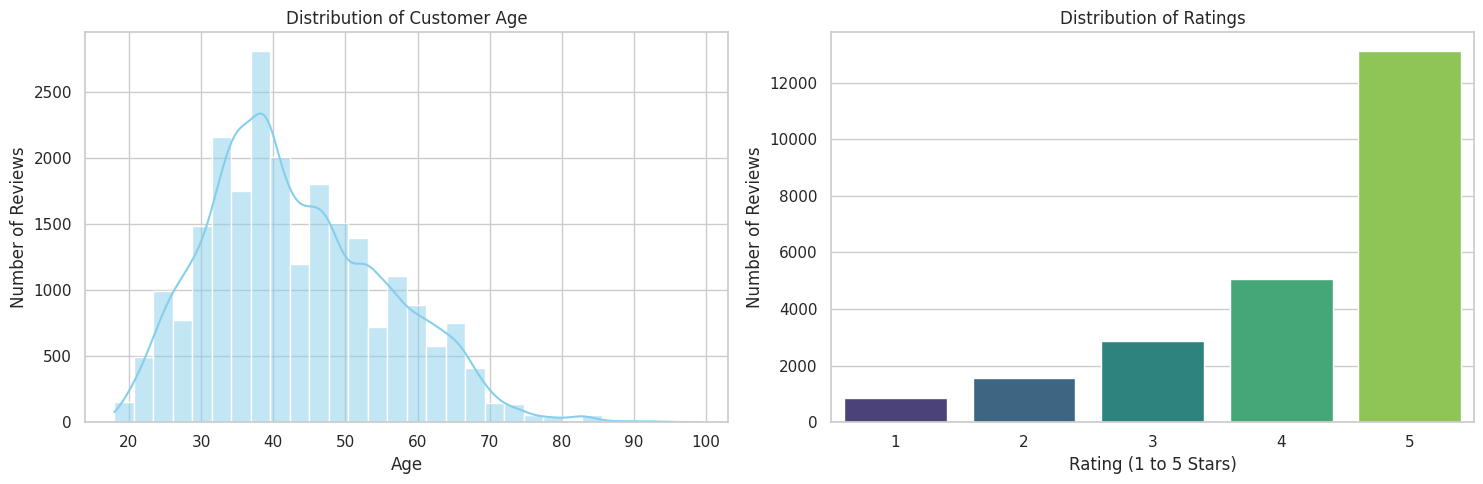

In [7]:
# Import our visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional visual style
sns.set_theme(style="whitegrid")

# Create a blank canvas that is wide enough for two charts side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- CHART 1: The Age Histogram ---
# A histogram groups ages into "bins" to show us where the bulk of our customers sit
sns.histplot(data=df, x='Age', bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Customer Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Reviews')

# --- CHART 2: The Rating Bar Chart ---
# A countplot simply counts how many times each rating appears
sns.countplot(data=df, x='Rating', palette='viridis', ax=axes[1])
axes[1].set_title('Distribution of Ratings')
axes[1].set_xlabel('Rating (1 to 5 Stars)')
axes[1].set_ylabel('Number of Reviews')

# Tell Python to display the charts neatly
plt.tight_layout()
plt.show()

**Insights from Univariate Analysis:**
* **Demographics:** The vast majority of our customers fall between the ages of 30 and 45. Marketing efforts should be optimized for this millennial/Gen-X cohort.
* **Sentiment:** Overall customer satisfaction is overwhelmingly positive, heavily skewed towards 5-star reviews.

## Step 4: Bivariate Analysis
Now we will look for relationships between variables to identify friction points. We want to determine if specific departments are underperforming and if customer age influences how harshly a product is rated.

/tmp/ipykernel_1347/3872981815.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Department Name', y='Rating', ax=axes[0], palette='muted')
/tmp/ipykernel_1347/3872981815.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Rating', y='Age', ax=axes[1], palette='pastel')


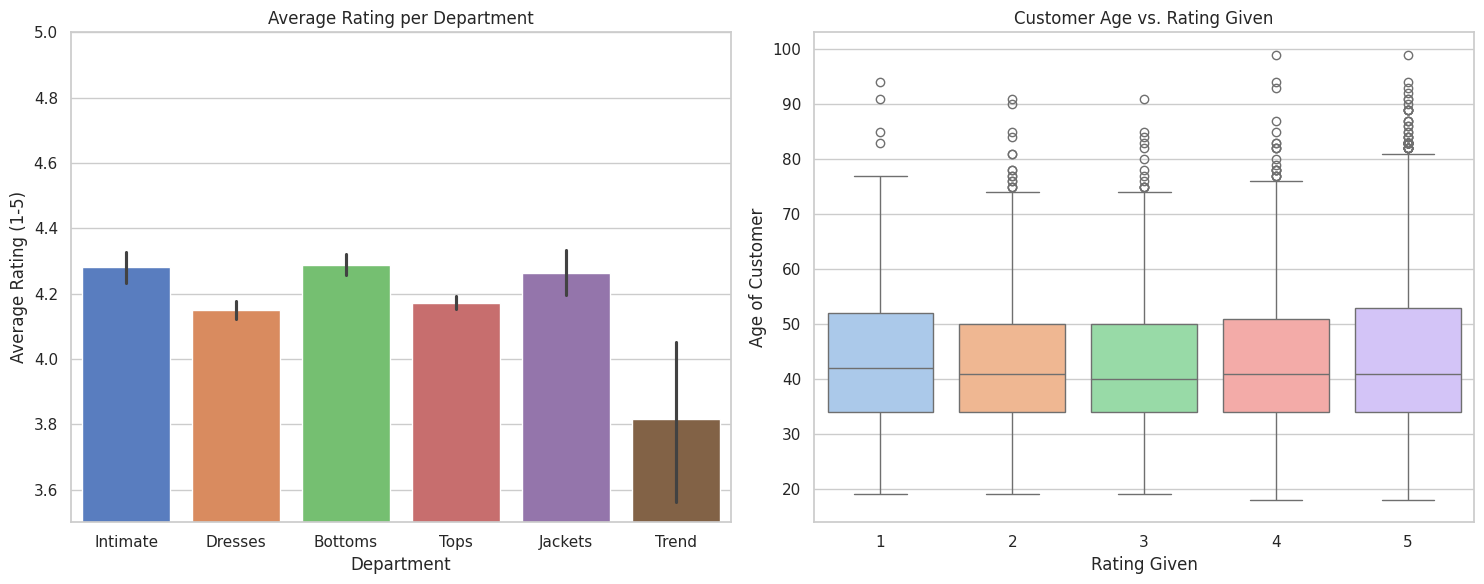

In [8]:
# Create a new canvas for our two bivariate charts
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- CHART 1: Rating by Department (Bar Plot) ---
# This calculates the AVERAGE rating for each clothing department
sns.barplot(data=df, x='Department Name', y='Rating', ax=axes[0], palette='muted')
axes[0].set_title('Average Rating per Department')
axes[0].set_ylabel('Average Rating (1-5)')
axes[0].set_xlabel('Department')
axes[0].set_ylim(3.5, 5) # We zoom in on the y-axis to see the differences more clearly

# --- CHART 2: Age vs. Rating (Box Plot) ---
# This shows the distribution of ages for EVERY rating category (1 through 5)
sns.boxplot(data=df, x='Rating', y='Age', ax=axes[1], palette='pastel')
axes[1].set_title('Customer Age vs. Rating Given')
axes[1].set_xlabel('Rating Given')
axes[1].set_ylabel('Age of Customer')

plt.tight_layout()
plt.show()

**Insights from Bivariate Analysis:**
* **Department Performance:** The 'Trend' department is the worst-performing category, followed closely by 'Dresses'. These areas require immediate quality audits.
* **Age vs. Rating:** The median age remains completely flat (around 40-42 years old) across all rating categories. This proves that dissatisfaction is tied to the physical product itself, not to a specific age demographic rejecting the style.

## Step 5: The Voice of the Customer (Text Analysis)
Since the 'Trend' department has the lowest average rating, we need to understand the *why*. We will filter our dataset to isolate only the 1-star and 2-star reviews specifically within the Trend department and read the raw customer feedback.

In [9]:
# 1. Create our filter conditions
# Notice we use == for "exactly matches" and <= for "less than or equal to"
# The & symbol tells Pandas that BOTH conditions must be true
bad_trend_reviews = df[(df['Department Name'] == 'Trend') & (df['Rating'] <= 2)]

# 2. We don't need all the columns now, just the text.
# Let's pull the 'Review Text' column and look at the first 5 entries.
print("--- THE VOICE OF THE CUSTOMER: TREND DEPT (1 & 2 STARS) --- \n")

# We use a simple loop to print them neatly with a blank line in between
for review in bad_trend_reviews['Review Text'].head(5):
    print("-", review)
    print()

--- THE VOICE OF THE CUSTOMER: TREND DEPT (1 & 2 STARS) --- 

- Finally received this in the mail today and was very disappointed. i am swimming in the xs (5'4", 110lbs). the colors are much more vibrant that shown in the pics - the green is a bright kelly green, the red is much more red than rust colored, etc. and it's a sweater coat! for the price i was expecting it to be lined and higher quality. i don't doubt that it will be warm, but can't justify the price. it's going back to the store.

- No Review

- The top is totally see through and fabric some what itchy.  it also feels cheap to the touch.  i love the idea but can't keep it for this price...i'm a shorty so i'd have to hem it too! sadly will return.

- I am not sure who would look good in this dress. it is extremely oversized with tons of fabric that will not flatter anyone!

- This runs sooo big! i normally wear a large ( 145lb, 5'-4", 36dd) but due to the limited sizing small or medium i chose small because it looked big on

## Final Business Recommendations
Based on the exploratory data analysis, including a deep dive into the written reviews of our lowest-performing department, I recommend the following actions:

1. **Audit Sizing Charts:** Customers consistently report that garments in the 'Trend' department are drastically oversized ("swimming in an XS", "could fit two people"). We must temporarily halt production to review sizing patterns and immediately advise online shoppers to "Size Down."
2. **Review Pricing Strategy:** Negative reviews frequently mention the material feeling "cheap" or "itchy," indicating that the high price point of the Trend line does not align with the material quality. We need to either source better fabrics or lower the price.
3. **Standardize Product Photography:** Customers note a severe mismatch between the muted colors shown online and the highly vibrant colors received in the mail. The e-commerce team must re-shoot these specific items under natural lighting to set accurate customer expectations and reduce the return rate.